In [31]:
#引入可视化，回归分析必要库
import pandas as pd
import statsmodels.api as sm            
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression   
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
#读取数据
df = pd.read_csv('/Users/jerryli/Desktop/MCM/data/df_clean_with_vote.csv')



In [32]:
df = df[~df['is_withdrew']]

In [33]:
df = df[(df['season'] != 1) & (df['season'] != 15)]

In [34]:
print(df.head())

    Unnamed: 0   celebrity_name    ballroom_partner celebrity_industry  \
6            6     Tatum O'Neal       Nick Kosovich      Actor/Actress   
7            7      Tia Carrere  Maksim Chmerkoskiy      Actor/Actress   
8            8  George Hamilton     Edyta Sliwinska      Actor/Actress   
9            9       Lisa Rinna    Louis van Amstel      Actor/Actress   
10          10    Stacy Keibler       Tony Dovolani            Athlete   

   celebrity_homestate celebrity_homecountry_region  \
6           California                United States   
7               Hawaii                United States   
8            Tennessee                United States   
9           California                United States   
10            Maryland                United States   

    celebrity_age_during_season  season            results  placement  ...  \
6                            42       2  Eliminated Week 2          9  ...   
7                            39       2  Eliminated Week 5          

In [35]:
import re

def extract_placement(result):
    if 'Withdrew' in result:
        return 0
    match = re.search(r'(\d+)', result)
    if match:
        return int(match.group(1))
    else:
        return None

df['placement'] = df['results'].apply(extract_placement)

In [36]:
print(df.groupby("season").size())

season
2     10
3     10
4     11
5     12
6     12
7     12
8     13
9     15
10    11
11    12
12    11
13    12
14    12
16    11
17    12
18    11
19    13
20    12
21    11
22    12
23    13
24    12
25    13
26    10
27    13
28    11
29    14
30    15
31    15
32    14
33    13
34    14
dtype: int64


In [37]:
# Calculate weekly average judge scores and drop original judge score columns
for week in range(1, 12):
    cols = [f'week{week}_judge{i}_score' for i in range(1, 5)]
    df[f'week{week}_judge_score_mean'] = df[cols].mean(axis=1)




In [38]:
for week in range(1, 12):
    def get_effective_score(row):
        for w in range(week, 0, -1):
            score = row[f'week{w}_judge_score_mean']
            if not pd.isna(score):
                return score
        return np.nan
    
    df[f'week{week}_effective_score'] = df.apply(get_effective_score, axis=1)
    
    # Rank within each season, higher score gets lower (better) placement number
    df[f'week{week}_judge_score_placement'] = df.groupby('season')[f'week{week}_effective_score'].rank(ascending=False, method='dense', na_option='keep')
    
    # Drop the intermediate effective_score column
    df.drop(columns=[f'week{week}_effective_score'], inplace=True)

In [39]:
for week in range(1, 12):
    def get_effective_score(row):
        for w in range(week, 0, -1):
            score = row[f'week{w}_judge_score_mean']
            if not pd.isna(score):
                return score
        return np.nan
    
    df[f'week{week}_effective_score'] = df.apply(get_effective_score, axis=1)
    
    # Rank within each season, higher score gets lower (better) placement number
    df[f'week{week}_judge_score_placement'] = df.groupby('season')[f'week{week}_effective_score'].rank(ascending=False, method='dense', na_option='keep')
    
    # Save count for later
    df[f'week{week}_effective_count'] = df.groupby('season')[f'week{week}_effective_score'].transform('count')
    
    # Drop the intermediate effective_score column
    df.drop(columns=[f'week{week}_effective_score'], inplace=True)

对于每一季内，week{i}_judge_score_placement_all = week{i}_judge_score_placement/当时这一季内week{i}_p_score不是NaN的人数，只需要i = 1，6和11周的数据

In [40]:
# 用保存的effective_count
df['week1_judge_score_placement_all'] = df['week1_judge_score_placement'] / df['week1_effective_count']
df['week6_judge_score_placement_all'] = df['week6_judge_score_placement'] / df['week6_effective_count']
df['week11_judge_score_placement_all'] = df['week11_judge_score_placement'] / df['week11_effective_count']

In [41]:
df = df[df['season'] != 15]

对于评委，我们由于季与季之间评委不同、加分机制的原因，认为选手的水平总体和季内打分尺度保持稳定，而季与季之间不具有直接可比性，所以主要以选手的评委打分的**季内排名**视作选手的初期和终期（4周之后最后一次）的表现（不考虑15周）。对于观众，我们认为观众的审美和人气尺度是在季与季之间是稳定的，所以季与季之间相同阶段的p值可以直接比较，但是季内由于是投票所以不具有评估选手表现的一致性，所以同一季不同时间进程的p不具有可比性，所以以每一季度的第一周、剩余6人的周和最后一周剩余的数据总 E(p)*存活选手数 为选手表现的判断依据。

In [42]:
df.drop(columns=['results'], inplace=True)

# 处理观众部分
删去1、15周的数据，对每一季度的第一周、剩余6人的周和最后一周剩余的数据先增加一列week1_p_score或者week6_p_score或者week_final_p_score = week?_p_mean*季度内这一周还有数据的人数，直接对所有数据进行week?_p_score的排序week?_p_score_placement

In [43]:

# Define necessary variables
max_weeks = df.groupby('season')['season_max_week'].max()
week1_counts = df.groupby('season')['week1_p_mean'].count()
week6_dict = pd.Series({
    2: 'week5_p_mean',
    3: None,
    4: 'week7_p_mean',
    5: 'week7_p_mean',
    6: 'week7_p_mean',
    7: 'week7_p_mean',
    8: 'week8_p_mean',
    9: None,
    10: 'week7_p_mean',
    11: 'week7_p_mean',
    12: 'week7_p_mean',
    13: 'week7_p_mean',
    14: 'week8_p_mean',
    16: 'week8_p_mean',
    17: 'week9_p_mean',
    18: 'week8_p_mean',
    19: 'week9_p_mean',
    20: 'week8_p_mean',
    21: 'week9_p_mean',
    22: 'week8_p_mean',
    23: 'week9_p_mean',
    24: None,
    25: 'week8_p_mean',
    26: 'week3_p_mean',
    27: 'week8_p_mean',
    28: 'week9_p_mean',
    29: 'week10_p_mean',
    30: 'week9_p_mean',
    31: 'week9_p_mean',
    32: 'week9_p_mean',
    33: 'week7_p_mean',
    34: 'week10_p_mean'
})
week6_counts = {}
for season in df['season'].unique():
    col = week6_dict.get(season)
    if col:
        count = df[df['season'] == season][col].count()
        week6_counts[season] = count

final_counts = {}
for season in df['season'].unique():
    max_w = df[df['season'] == season]['season_max_week'].max()
    col = f'week{max_w}_p_mean'
    count = df[df['season'] == season][col].count()
    final_counts[season] = count

# Calculate week1_p_score and placement
df['week1_p_score'] = df['week1_p_mean'] * df['season'].map(week1_counts)
df['week1_p_score_placement'] = df['week1_p_score'].rank(ascending=False, method='dense', na_option='keep')

# Calculate week6_p_score and placement
df['week6_p_score'] = df.apply(lambda row: row[week6_dict[row['season']]] * week6_counts.get(row['season'], np.nan) if week6_dict.get(row['season']) else np.nan, axis=1)
df['week6_p_score_placement'] = df['week6_p_score'].rank(ascending=False, method='dense', na_option='keep')

# Calculate week_final_p_score and placement
df['week_final_p_score'] = df.apply(lambda row: row[f'week{max_weeks[row["season"]]}_p_mean'] * final_counts[row['season']], axis=1)
df['week_final_p_score_placement'] = df['week_final_p_score'].rank(ascending=False, method='dense', na_option='keep')

In [44]:
print(df)

     Unnamed: 0   celebrity_name                          ballroom_partner  \
6             6     Tatum O'Neal                             Nick Kosovich   
7             7      Tia Carrere                        Maksim Chmerkoskiy   
8             8  George Hamilton                           Edyta Sliwinska   
9             9       Lisa Rinna                          Louis van Amstel   
10           10    Stacy Keibler                             Tony Dovolani   
..          ...              ...                                       ...   
416         416     Scott Hoying                              Rylee Arnold   
417         417       Alix Earle  Val Chmerkovskiy (Joey Graziadei week 9)   
418         418      Jen Affleck                                Jan Ravnik   
419         419  Whitney Leavitt                               Mark Ballas   
420         420      Dylan Efron   Daniella Karagach (Rumer Willis week 9)   

           celebrity_industry celebrity_homestate  \
6         

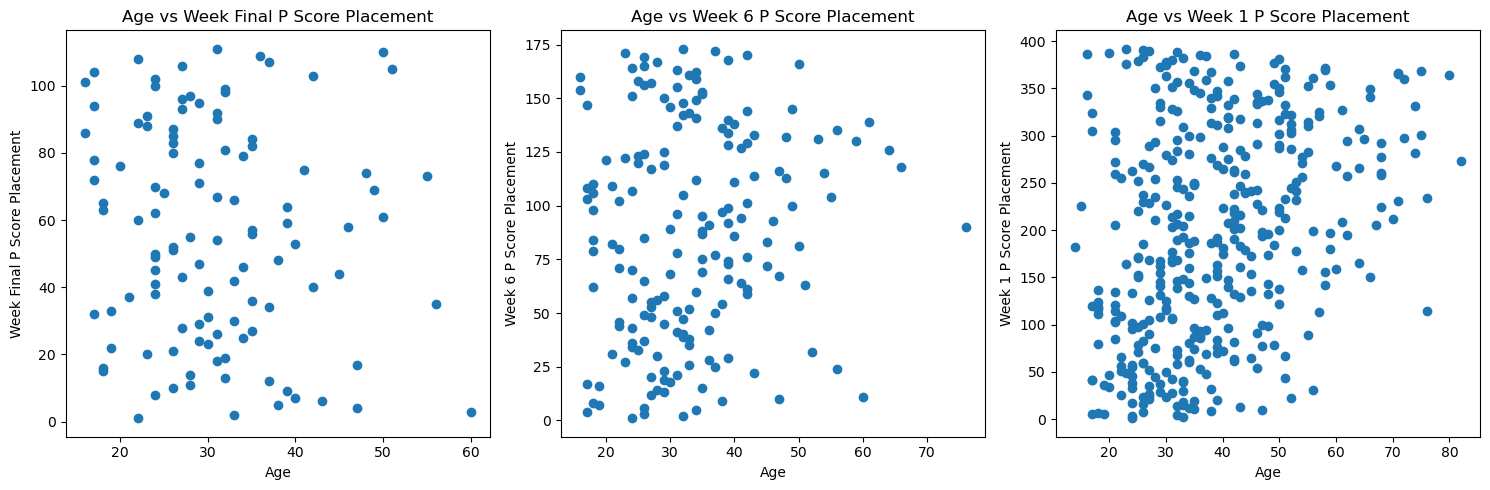

In [45]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scatter plot for week_final_p_score_placement
axes[0].scatter(df['celebrity_age_during_season'], df['week_final_p_score_placement'])
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Week Final P Score Placement')
axes[0].set_title('Age vs Week Final P Score Placement')

# Scatter plot for week6_p_score_placement
axes[1].scatter(df['celebrity_age_during_season'], df['week6_p_score_placement'])
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Week 6 P Score Placement')
axes[1].set_title('Age vs Week 6 P Score Placement')

# Scatter plot for week1_p_score_placement
axes[2].scatter(df['celebrity_age_during_season'], df['week1_p_score_placement'])
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Week 1 P Score Placement')
axes[2].set_title('Age vs Week 1 P Score Placement')

plt.tight_layout()
plt.show()

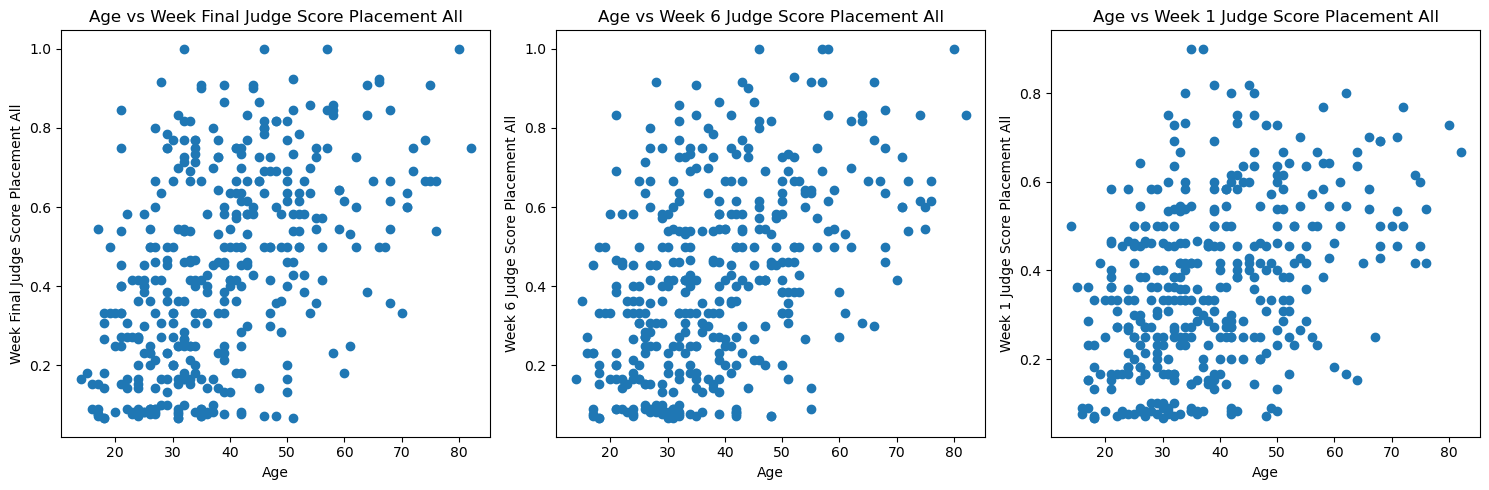

In [46]:
# Plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scatter plot for week_final_judge_score_placement_all
axes[0].scatter(df['celebrity_age_during_season'], df['week11_judge_score_placement_all'])
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Week Final Judge Score Placement All')
axes[0].set_title('Age vs Week Final Judge Score Placement All')

# Scatter plot for week6_judge_score_placement_all
axes[1].scatter(df['celebrity_age_during_season'], df['week6_judge_score_placement_all'])
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Week 6 Judge Score Placement All')
axes[1].set_title('Age vs Week 6 Judge Score Placement All')

# Scatter plot for week1_judge_score_placement_all
axes[2].scatter(df['celebrity_age_during_season'], df['week1_judge_score_placement_all'])
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Week 1 Judge Score Placement All')
axes[2].set_title('Age vs Week 1 Judge Score Placement All')

plt.tight_layout()
plt.show()

In [47]:
#专业舞者分析
# Calculate total contestants per season
total_contestants = df.groupby('season').size()+1

# Create placement_all column
df['placement_all'] = df['placement'] / df['season'].map(total_contestants)
print(df.placement_all.describe())
print(df)

count    392.000000
mean       0.344362
std        0.208611
min        0.062500
25%        0.166667
50%        0.285714
75%        0.500000
max        0.916667
Name: placement_all, dtype: float64
     Unnamed: 0   celebrity_name                          ballroom_partner  \
6             6     Tatum O'Neal                             Nick Kosovich   
7             7      Tia Carrere                        Maksim Chmerkoskiy   
8             8  George Hamilton                           Edyta Sliwinska   
9             9       Lisa Rinna                          Louis van Amstel   
10           10    Stacy Keibler                             Tony Dovolani   
..          ...              ...                                       ...   
416         416     Scott Hoying                              Rylee Arnold   
417         417       Alix Earle  Val Chmerkovskiy (Joey Graziadei week 9)   
418         418      Jen Affleck                                Jan Ravnik   
419         419  Whitney

In [48]:
df_partner = df.groupby('ballroom_partner').agg(
    count=('ballroom_partner', 'size'),
    avg_placement=('placement_all', 'mean'),
    avg_week1_p_score_placement=('week1_p_score_placement', 'mean'),
    avg_week6_p_score_placement=('week6_p_score_placement', 'mean'),
    avg_week_final_p_score_placement=('week_final_p_score_placement', 'mean'),
    avg_week1_judge_score_placement_all=('week1_judge_score_placement_all', 'mean'),
    avg_week6_judge_score_placement_all=('week6_judge_score_placement_all', 'mean'),
    avg_week11_judge_score_placement_all=('week11_judge_score_placement_all', 'mean')
).reset_index()

print(df_partner)

                            ballroom_partner  count  avg_placement  \
0                               Alan Bersten      9       0.261388   
1      Alan Bersten (Rashad Jennings week 9)      1       0.333333   
2                                  Alec Mazo      4       0.235176   
3                             Allison Holker      4       0.383700   
4                                Andrea Hale      1       0.090909   
5                              Anna Demidova      1       0.437500   
6                           Anna Trebunskaya     10       0.288054   
7                          Artem Chigvintsev     12       0.375269   
8                            Ashly DelGrosso      3       0.295455   
9                          Brandon Armstrong      7       0.306548   
10                             Brian Fortuna      1       0.250000   
11                             Britt Stewart      6       0.328075   
12                         Chelsie Hightower      6       0.504197   
13                  

In [49]:


# Group by ballroom_partner and count occurrences
partner_counts = df.groupby('ballroom_partner').size()

# Filter partners who appear more than 5 times
partners_more_than_5 = partner_counts[partner_counts > 5].index

# Filter the dataframe for these partners
filtered_df = df[df['ballroom_partner'].isin(partners_more_than_5)]

# Calculate mean placement_all for each partner
partner_means = filtered_df.groupby('ballroom_partner')['placement_all'].mean()

# Sort the partners by mean placement_all (ascending, lower is better)
sorted_partners = partner_means.sort_values()

# Display the sorted partners with their mean placement_all
print(sorted_partners)

ballroom_partner
Jonathan Roberts         0.227117
Jenna Johnson            0.227958
Keo Motsepe              0.245728
Alan Bersten             0.261388
Anna Trebunskaya         0.288054
Pasha Pashkov            0.293622
Mark Ballas              0.304796
Brandon Armstrong        0.306548
Lacey Schwimmer          0.313149
Valentin Chmerkovskiy    0.313343
Britt Stewart            0.328075
Sharna Burgess           0.328594
Edyta Sliwinska          0.329735
Gleb Savchenko           0.340687
Karina Smirnoff          0.341012
Witney Carson            0.341203
Kym Johnson              0.347503
Lindsay Arnold           0.356369
Maksim Chmerkoskiy       0.373656
Artem Chigvintsev        0.375269
Tony Dovolani            0.382495
Derek Hough              0.382970
Cheryl Burke             0.396541
Peta Murgatroyd          0.404595
Emma Slater              0.426308
Louis van Amstel         0.456002
Sasha Farber             0.456899
Chelsie Hightower        0.504197
Name: placement_all, dtype: flo

In [50]:

# Step 1: 计算每周存活人数（按赛季统计非NaN行数）
def get_weekly_survivors(df, week_col, season_col='season'):
    """计算每赛季每周的存活人数（该周有分数的人数）"""
    survivors = df.groupby(season_col)[week_col].apply(lambda x: x.notna().sum())
    return survivors

# 计算各周存活人数
week1_survivors = get_weekly_survivors(df, 'week1_judge_score_placement')
week6_survivors = get_weekly_survivors(df, 'week6_judge_score_placement')
week11_survivors = get_weekly_survivors(df, 'week11_judge_score_placement')

print("各周存活人数：")
print(f"Week1: {week1_survivors.to_dict()}")
print(f"Week6: {week6_survivors.to_dict()}")
print(f"Week11: {week11_survivors.to_dict()}")

# 同时计算赛季总人数（用于placement）
season_total = df.groupby('season').size()
print(f"\n赛季总人数: {season_total.to_dict()}")


各周存活人数：
Week1: {2: 10, 3: 10, 4: 11, 5: 12, 6: 12, 7: 12, 8: 13, 9: 15, 10: 11, 11: 12, 12: 11, 13: 12, 14: 12, 16: 11, 17: 12, 18: 11, 19: 13, 20: 12, 21: 11, 22: 12, 23: 13, 24: 12, 25: 13, 26: 10, 27: 13, 28: 11, 29: 14, 30: 15, 31: 15, 32: 14, 33: 13, 34: 14}
Week6: {2: 10, 3: 10, 4: 11, 5: 12, 6: 12, 7: 12, 8: 13, 9: 15, 10: 11, 11: 12, 12: 11, 13: 12, 14: 12, 16: 11, 17: 12, 18: 11, 19: 13, 20: 12, 21: 11, 22: 12, 23: 13, 24: 12, 25: 13, 26: 10, 27: 13, 28: 11, 29: 14, 30: 15, 31: 15, 32: 14, 33: 13, 34: 14}
Week11: {2: 10, 3: 10, 4: 11, 5: 12, 6: 12, 7: 12, 8: 13, 9: 15, 10: 11, 11: 12, 12: 11, 13: 12, 14: 12, 16: 11, 17: 12, 18: 11, 19: 13, 20: 12, 21: 11, 22: 12, 23: 13, 24: 12, 25: 13, 26: 10, 27: 13, 28: 11, 29: 14, 30: 15, 31: 15, 32: 14, 33: 13, 34: 14}

赛季总人数: {2: 10, 3: 10, 4: 11, 5: 12, 6: 12, 7: 12, 8: 13, 9: 15, 10: 11, 11: 12, 12: 11, 13: 12, 14: 12, 16: 11, 17: 12, 18: 11, 19: 13, 20: 12, 21: 11, 22: 12, 23: 13, 24: 12, 25: 13, 26: 10, 27: 13, 28: 11, 29: 14, 30: 15

In [51]:

# Step 2: 转换为击败比例（beat_ratio）
def placement_to_beat_ratio(placement_series, n_contestants_series):
    """
    将排名转换为击败比例
    beat_ratio = (n - placement) / (n - 1)
    placement=1 → 1.0, placement=n → 0.0
    """
    # 避免除以0（当n=1时，唯一选手击败比例定义为1.0）
    denominator = np.where(n_contestants_series > 1, n_contestants_series - 1, 1)
    beat_ratio = (n_contestants_series - placement_series) / denominator
    # 当n=1时，强制为1.0
    beat_ratio = np.where(n_contestants_series == 1, 1.0, beat_ratio)
    return beat_ratio

# 创建df3（保留原始列）
df3 = df.copy()

# 2.1 placement → beat_ratio
df3['placement_beat_ratio'] = placement_to_beat_ratio(
    df3['placement'], 
    df3['season'].map(season_total)
)

# 2.2 week1_judge_score_placement → beat_ratio
df3['week1_survivors'] = df3['season'].map(week1_survivors)
df3['week1_judge_beat_ratio'] = placement_to_beat_ratio(
    df3['week1_judge_score_placement'],
    df3['week1_survivors']
)

# 2.3 week6_judge_score_placement → beat_ratio
df3['week6_survivors'] = df3['season'].map(week6_survivors)
df3['week6_judge_beat_ratio'] = placement_to_beat_ratio(
    df3['week6_judge_score_placement'],
    df3['week6_survivors']
)

# 2.4 week11_judge_score_placement → beat_ratio
df3['week11_survivors'] = df3['season'].map(week11_survivors)
df3['week11_judge_beat_ratio'] = placement_to_beat_ratio(
    df3['week11_judge_score_placement'],
    df3['week11_survivors']
)

print("击败比例（中间步骤）：")
print(df3[['celebrity_name', 'season', 'placement', 'placement_beat_ratio',
           'week1_judge_score_placement', 'week1_judge_beat_ratio',
           'week6_judge_score_placement', 'week6_judge_beat_ratio']])


击败比例（中间步骤）：
      celebrity_name  season  placement  placement_beat_ratio  \
6       Tatum O'Neal       2          2              0.888889   
7        Tia Carrere       2          5              0.555556   
8    George Hamilton       2          6              0.444444   
9         Lisa Rinna       2          7              0.333333   
10     Stacy Keibler       2          3              0.777778   
..               ...     ...        ...                   ...   
416     Scott Hoying      34          6              0.615385   
417       Alix Earle      34          2              0.923077   
418      Jen Affleck      34          7              0.538462   
419  Whitney Leavitt      34         10              0.307692   
420      Dylan Efron      34          4              0.769231   

     week1_judge_score_placement  week1_judge_beat_ratio  \
6                            2.0                0.888889   
7                            5.0                0.555556   
8                          

In [52]:


season_total_corrected = df.groupby('season')['placement'].max()
print(f"\n修正后赛季总人数（max placement）: {season_total_corrected.to_dict()}")

# 重新计算
df3['placement_beat_ratio'] = placement_to_beat_ratio(
    df3['placement'], 
    df3['season'].map(season_total_corrected)
)

print("\n修正后的击败比例：")
print(df3[['celebrity_name', 'season', 'placement', 'placement_beat_ratio']])



修正后赛季总人数（max placement）: {2: 7, 3: 8, 4: 9, 5: 9, 6: 9, 7: 9, 8: 10, 9: 9, 10: 9, 11: 9, 12: 9, 13: 9, 14: 9, 16: 10, 17: 11, 18: 10, 19: 11, 20: 9, 21: 11, 22: 9, 23: 11, 24: 9, 25: 10, 26: 3, 27: 8, 28: 10, 29: 10, 30: 9, 31: 9, 32: 9, 33: 7, 34: 10}

修正后的击败比例：
      celebrity_name  season  placement  placement_beat_ratio
6       Tatum O'Neal       2          2              0.833333
7        Tia Carrere       2          5              0.333333
8    George Hamilton       2          6              0.166667
9         Lisa Rinna       2          7              0.000000
10     Stacy Keibler       2          3              0.666667
..               ...     ...        ...                   ...
416     Scott Hoying      34          6              0.444444
417       Alix Earle      34          2              0.888889
418      Jen Affleck      34          7              0.333333
419  Whitney Leavitt      34         10              0.000000
420      Dylan Efron      34          4              

In [53]:

# 重新清理，使用正确的逻辑
# 对于评委排名，应该用该周实际存活人数，而不是max placement

df3 = df.copy()

# 重新计算各类人数
season_total = df.groupby('season')['placement'].max()  # 赛季总人数

# 计算每周存活人数（有分数的非NaN人数）
week1_survivors = get_weekly_survivors(df, 'week1_judge_score_placement')
week6_survivors = get_weekly_survivors(df, 'week6_judge_score_placement')
week11_survivors = get_weekly_survivors(df, 'week11_judge_score_placement')

print(f"赛季总人数: {season_total.to_dict()}")
print(f"Week1存活: {week1_survivors.to_dict()}")
print(f"Week6存活: {week6_survivors.to_dict()}")
print(f"Week11存活: {week11_survivors.to_dict()}")

# 定义击败比例转换函数（保持NaN）
def safe_placement_to_beat_ratio(placement, n_total):
    """安全转换，保持NaN，处理边界情况"""
    if pd.isna(placement) or pd.isna(n_total) or n_total <= 0:
        return np.nan
    if n_total == 1:
        return 1.0  # 唯一选手
    return (n_total - placement) / (n_total - 1)

# 向量化版本
vec_beat_ratio = np.vectorize(safe_placement_to_beat_ratio)

# 1. placement → beat_ratio
df3['placement_br'] = vec_beat_ratio(
    df3['placement'].values,
    df3['season'].map(season_total).values
)

# 2. week1_judge_score_placement → beat_ratio
df3['week1_br'] = vec_beat_ratio(
    df3['week1_judge_score_placement'].values,
    df3['season'].map(week1_survivors).values
)

# 3. week6_judge_score_placement → beat_ratio
df3['week6_br'] = vec_beat_ratio(
    df3['week6_judge_score_placement'].values,
    df3['season'].map(week6_survivors).values
)

# 4. week11_judge_score_placement → beat_ratio
df3['week11_br'] = vec_beat_ratio(
    df3['week11_judge_score_placement'].values,
    df3['season'].map(week11_survivors).values
)

print("\n击败比例预览：")
print(df3[['celebrity_name', 'placement_br', 'week1_br', 'week6_br', 'week11_br']])


赛季总人数: {2: 7, 3: 8, 4: 9, 5: 9, 6: 9, 7: 9, 8: 10, 9: 9, 10: 9, 11: 9, 12: 9, 13: 9, 14: 9, 16: 10, 17: 11, 18: 10, 19: 11, 20: 9, 21: 11, 22: 9, 23: 11, 24: 9, 25: 10, 26: 3, 27: 8, 28: 10, 29: 10, 30: 9, 31: 9, 32: 9, 33: 7, 34: 10}
Week1存活: {2: 10, 3: 10, 4: 11, 5: 12, 6: 12, 7: 12, 8: 13, 9: 15, 10: 11, 11: 12, 12: 11, 13: 12, 14: 12, 16: 11, 17: 12, 18: 11, 19: 13, 20: 12, 21: 11, 22: 12, 23: 13, 24: 12, 25: 13, 26: 10, 27: 13, 28: 11, 29: 14, 30: 15, 31: 15, 32: 14, 33: 13, 34: 14}
Week6存活: {2: 10, 3: 10, 4: 11, 5: 12, 6: 12, 7: 12, 8: 13, 9: 15, 10: 11, 11: 12, 12: 11, 13: 12, 14: 12, 16: 11, 17: 12, 18: 11, 19: 13, 20: 12, 21: 11, 22: 12, 23: 13, 24: 12, 25: 13, 26: 10, 27: 13, 28: 11, 29: 14, 30: 15, 31: 15, 32: 14, 33: 13, 34: 14}
Week11存活: {2: 10, 3: 10, 4: 11, 5: 12, 6: 12, 7: 12, 8: 13, 9: 15, 10: 11, 11: 12, 12: 11, 13: 12, 14: 12, 16: 11, 17: 12, 18: 11, 19: 13, 20: 12, 21: 11, 22: 12, 23: 13, 24: 12, 25: 13, 26: 10, 27: 13, 28: 11, 29: 14, 30: 15, 31: 15, 32: 14, 33: 13

In [54]:

# Step 3: 计算全局Z分数

def calculate_global_z(series):
    """
    计算全局Z分数，保持NaN
    Z = (x - mean) / std
    注意：对于beat_ratio，越大越好，所以不需要反转
    对于p_score_placement（全局排名），需要反转（排名1 → Z大）
    """
    # 只使用非NaN值计算统计量
    valid_data = series.dropna()
    if len(valid_data) <= 1:
        # 如果只有一个有效值，Z分数为0（或保持NaN）
        return series.apply(lambda x: 0.0 if pd.notna(x) else np.nan)
    
    mean = valid_data.mean()
    std = valid_data.std(ddof=0)  # 总体标准差
    
    if std == 0:
        return series.apply(lambda x: 0.0 if pd.notna(x) else np.nan)
    
    z_scores = (series - mean) / std
    return z_scores

# 3.1 placement_beat_ratio → Z
df3['placement_z'] = calculate_global_z(df3['placement_br'])

# 3.2 week1_judge_beat_ratio → Z
df3['week1_judge_score_placement_z'] = calculate_global_z(df3['week1_br'])

# 3.3 week6_judge_beat_ratio → Z
df3['week6_judge_score_placement_z'] = calculate_global_z(df3['week6_br'])

# 3.4 week11_judge_beat_ratio → Z
df3['week11_judge_score_placement_z'] = calculate_global_z(df3['week11_br'])

# 3.5 p_score_placement（全局排名）→ 先反转再Z分数
# 反转：排名越小越好 → 用负排名或 (max_rank + 1 - rank)
for col in ['week1_p_score_placement', 'week6_p_score_placement', 'week_final_p_score_placement']:
    # 创建反转分数（越大越好）
    max_rank = df3[col].max()  # 全局最大排名
    reversed_score = max_rank + 1 - df3[col]  # 排名1 → max_score, 排名max → 1
    df3[f'{col}_z'] = calculate_global_z(reversed_score)

print("Z分数结果：")
z_cols = ['placement_z', 'week1_judge_score_placement_z', 'week6_judge_score_placement_z', 
          'week11_judge_score_placement_z', 'week1_p_score_placement_z', 
          'week6_p_score_placement_z', 'week_final_p_score_placement_z']
print(df3[['celebrity_name'] + z_cols])


Z分数结果：
      celebrity_name  placement_z  week1_judge_score_placement_z  \
6       Tatum O'Neal     0.839394                       0.965476   
7        Tia Carrere    -0.679008                      -0.628707   
8    George Hamilton    -1.185142                      -1.691495   
9         Lisa Rinna    -1.691276                      -1.160101   
10     Stacy Keibler     0.333260                       0.434081   
..               ...          ...                            ...   
416     Scott Hoying    -0.341585                       0.025317   
417       Alix Earle     1.008106                       0.761093   
418      Jen Affleck    -0.679008                       0.393205   
419  Whitney Leavitt    -1.691276                       1.496870   
420      Dylan Efron     0.333260                       0.025317   

     week6_judge_score_placement_z  week11_judge_score_placement_z  \
6                        -0.282072                       -0.993837   
7                         0.150502  

In [55]:

# Step 4: 整理最终df3，保留需要的列

# 基础信息列
base_cols = [
    'celebrity_name', 'ballroom_partner', 'celebrity_industry',
    'celebrity_homestate', 'celebrity_homecountry_region',
    'celebrity_age_during_season', 'season', 'placement'
]

# Z分数列（按你要求的命名）
z_cols_final = [
    'placement_z',
    'week1_judge_score_placement_z',
    'week6_judge_score_placement_z', 
    'week11_judge_score_placement_z',
    'week1_p_score_placement_z',
    'week6_p_score_placement_z',
    'week_final_p_score_placement_z'
]

# 创建最终df3
df3_final = df3[base_cols + z_cols_final].copy()

print("最终df3：")
print(df3_final)
print(f"\n形状: {df3_final.shape}")
print(f"\n列名: {df3_final.columns.tolist()}")

# 验证统计
print("\n=== 验证统计 ===")
for col in z_cols_final:
    valid_count = df3_final[col].notna().sum()
    mean_val = df3_final[col].mean()
    std_val = df3_final[col].std()
    print(f"{col}: 非NaN={valid_count}, 均值={mean_val:.4f}, 标准差={std_val:.4f}")


最终df3：
      celebrity_name                          ballroom_partner  \
6       Tatum O'Neal                             Nick Kosovich   
7        Tia Carrere                        Maksim Chmerkoskiy   
8    George Hamilton                           Edyta Sliwinska   
9         Lisa Rinna                          Louis van Amstel   
10     Stacy Keibler                             Tony Dovolani   
..               ...                                       ...   
416     Scott Hoying                              Rylee Arnold   
417       Alix Earle  Val Chmerkovskiy (Joey Graziadei week 9)   
418      Jen Affleck                                Jan Ravnik   
419  Whitney Leavitt                               Mark Ballas   
420      Dylan Efron   Daniella Karagach (Rumer Willis week 9)   

           celebrity_industry celebrity_homestate  \
6               Actor/Actress          California   
7               Actor/Actress              Hawaii   
8               Actor/Actress           T

In [56]:

# 封装成完整函数，方便你直接应用到真实数据

def create_df3_with_zscores(df):
    """
    创建带Z分数的df3
    
    处理逻辑：
    1. placement, week{i}_judge_score_placement: 赛季内排名 → 击败比例 → 全局Z
    2. week{i}_p_score_placement: 全局排名 → 反转 → 全局Z
    3. 所有NaN保持NaN
    """
    df3 = df.copy()
    
    # 计算各类基数
    season_total = df.groupby('season')['placement'].max()  # 赛季总人数
    
    # 每周存活人数（有分数的人数）
    week_survivors = {}
    for week in [1, 6, 11]:
        col = f'week{week}_judge_score_placement'
        if col in df.columns:
            week_survivors[week] = df.groupby('season')[col].apply(lambda x: x.notna().sum())
    
    # 击败比例转换函数
    def to_beat_ratio(placement, n_total):
        if pd.isna(placement) or pd.isna(n_total) or n_total <= 0:
            return np.nan
        if n_total == 1:
            return 1.0
        return (n_total - placement) / (n_total - 1)
    
    vec_beat_ratio = np.vectorize(to_beat_ratio)
    
    # 计算击败比例
    # placement
    df3['placement_br'] = vec_beat_ratio(
        df3['placement'].values,
        df3['season'].map(season_total).values
    )
    
    # week1,6,11 judge scores
    for week in [1, 6, 11]:
        col = f'week{week}_judge_score_placement'
        br_col = f'week{week}_br'
        if col in df.columns:
            df3[br_col] = vec_beat_ratio(
                df3[col].values,
                df3['season'].map(week_survivors[week]).values
            )
    
    # 全局Z分数计算函数
    def global_z(series):
        valid = series.dropna()
        if len(valid) <= 1:
            return series.apply(lambda x: 0.0 if pd.notna(x) else np.nan)
        mean, std = valid.mean(), valid.std(ddof=0)
        if std == 0:
            return series.apply(lambda x: 0.0 if pd.notna(x) else np.nan)
        return (series - mean) / std
    
    # 计算Z分数
    # placement
    df3['placement_z'] = global_z(df3['placement_br'])
    
    # week1,6,11 judge placements
    for week in [1, 6, 11]:
        col = f'week{week}_judge_score_placement'
        z_col = f'{col}_z'
        br_col = f'week{week}_br'
        if col in df.columns:
            df3[z_col] = global_z(df3[br_col])
    
    # p_score placements（全局排名，需要反转）
    for col in ['week1_p_score_placement', 'week6_p_score_placement', 'week_final_p_score_placement']:
        if col in df.columns:
            z_col = f'{col}_z'
            # 反转：排名1 → 高分
            max_rank = df3[col].max()
            reversed_score = max_rank + 1 - df3[col]
            df3[z_col] = global_z(reversed_score)
    
    # 选择最终列
    base_cols = [
        'celebrity_name', 'ballroom_partner', 'celebrity_industry',
        'celebrity_homestate', 'celebrity_homecountry_region',
        'celebrity_age_during_season', 'season', 'placement'
    ]
    
    z_cols = [
        'placement_z',
        'week1_judge_score_placement_z',
        'week6_judge_score_placement_z',
        'week11_judge_score_placement_z',
        'week1_p_score_placement_z',
        'week6_p_score_placement_z',
        'week_final_p_score_placement_z'
    ]
    
    # 只保留存在的列
    final_cols = [c for c in base_cols + z_cols if c in df3.columns]
    
    return df3[final_cols]

# 测试
print("=== 使用封装函数 ===")
df3_result = create_df3_with_zscores(df)
print(df3_result)
print(f"\n形状: {df3_result.shape}")


=== 使用封装函数 ===
      celebrity_name                          ballroom_partner  \
6       Tatum O'Neal                             Nick Kosovich   
7        Tia Carrere                        Maksim Chmerkoskiy   
8    George Hamilton                           Edyta Sliwinska   
9         Lisa Rinna                          Louis van Amstel   
10     Stacy Keibler                             Tony Dovolani   
..               ...                                       ...   
416     Scott Hoying                              Rylee Arnold   
417       Alix Earle  Val Chmerkovskiy (Joey Graziadei week 9)   
418      Jen Affleck                                Jan Ravnik   
419  Whitney Leavitt                               Mark Ballas   
420      Dylan Efron   Daniella Karagach (Rumer Willis week 9)   

           celebrity_industry celebrity_homestate  \
6               Actor/Actress          California   
7               Actor/Actress              Hawaii   
8               Actor/Actress    

In [61]:
df3_result.to_csv("data_3.csv")

In [58]:
df3_result.columns

Index(['celebrity_name', 'ballroom_partner', 'celebrity_industry',
       'celebrity_homestate', 'celebrity_homecountry_region',
       'celebrity_age_during_season', 'season', 'placement', 'placement_z',
       'week1_judge_score_placement_z', 'week6_judge_score_placement_z',
       'week11_judge_score_placement_z', 'week1_p_score_placement_z',
       'week6_p_score_placement_z', 'week_final_p_score_placement_z'],
      dtype='object')

In [59]:
df3_result.head()

,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry_region,celebrity_age_during_season,season,placement,placement_z,week1_judge_score_placement_z,week6_judge_score_placement_z,week11_judge_score_placement_z,week1_p_score_placement_z,week6_p_score_placement_z,week_final_p_score_placement_z
6,Tatum O'Neal,Nick Kosovich,Actor/Actress,California,United States,42,2,2,0.839394,0.965476,-0.282072,-0.993837,-1.259276,NaN,NaN
7,Tia Carrere,Maksim Chmerkoskiy,Actor/Actress,Hawaii,United States,39,2,5,-0.679008,-0.628707,0.150502,-0.586122,0.039767,-1.061274,NaN
8,George Hamilton,Edyta Sliwinska,Actor/Actress,Tennessee,United States,66,2,6,-1.185142,-1.691495,0.583077,-0.178406,0.402085,-0.620745,NaN
9,Lisa Rinna,Louis van Amstel,Actor/Actress,California,United States,42,2,7,-1.691276,-1.160101,1.015651,0.229310,1.170906,0.520625,NaN
10,Stacy Keibler,Tony Dovolani,Athlete,Maryland,United States,26,2,3,0.333260,0.434081,1.448225,1.044741,1.215091,-1.641972,-0.749025
